Step1: LOAD DATASET AND CHECK COLUMN TYPES


In [16]:
#import packages that are requires
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder


In [17]:
#loading our dataset
data = pd.read_csv("medical_dataset_realistic_v2.csv")

In [18]:
#dropping unnecessary columns for training
drop_cols = ["patient_id", "timestamp"]
data = data.drop(columns=drop_cols, errors="ignore")

In [19]:
target = "MDR_label"
y = data[target]
X = data.drop(columns=[target])

In [20]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

In [21]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

In [22]:
print("Numeric Columns:", numeric_cols)
print("\nCategorical Columns:", categorical_cols)
print("\nTarget Column:", target)

print("\nData Loaded Successfully.")

Numeric Columns: ['age', 'duration_hours', 'temp_c', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'wbc_count', 'nurse_contact_count', 'surface_contamination_score', 'ventilation_quality_index', 'prior_admissions_6months', 'antibiotic_resistance_marker']

Categorical Columns: ['gender', 'ward', 'movement_path', 'equipment_used', 'comorbidity', 'sputum_result', 'antibiotic_given']

Target Column: MDR_label

Data Loaded Successfully.


**Step 2: HANDLE MISSING VALUES (IMPUTATION)**

In [23]:
numeric_imputer = SimpleImputer(strategy="median")

In [24]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

In [25]:
X_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(X[numeric_cols]),
    columns=numeric_cols
)

In [26]:
X_categorical = pd.DataFrame(
    categorical_imputer.fit_transform(X[categorical_cols]),
    columns=categorical_cols
)

print("Numeric and categorical missing values handled successfully.")

Numeric and categorical missing values handled successfully.


**STEP 3: ENCODING & TRAIN/TEST SPLIT**

convert categorical columns into numbers through encoding

We use One-Hot Encoding, which converts each category into a separate 0/1 column.

In [27]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [28]:
X_encoded = pd.DataFrame(
    encoder.fit_transform(X_categorical),
    columns=encoder.get_feature_names_out(categorical_cols)
)


X_final = pd.concat([X_numeric, X_encoded], axis=1)

print("Encoding completed. Final feature set created.")
print("Final number of features:", X_final.shape[1])


Encoding completed. Final feature set created.
Final number of features: 47


**STEP 3(b) — TRAIN / TEST SPLIT**

We must test the model on new unseen data.
So we split the dataset:

80% for training

20% for testing

We also use stratify=y to make sure MDR and Non-MDR labels are balanced.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
print("Training and testing sets created successfully.")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training and testing sets created successfully.
Training shape: (1200, 47)
Testing shape: (300, 47)


**STEP 4 — TRAIN RANDOM FOREST**

Random Forest is one of the best models for medical datasets because:

It can learn complex patterns

It handles noisy real-world clinical data well

It is resistant to overfitting when tuned properly

It works with both numeric and encoded categorical features

We create the model

Train (fit) it on X_train and y_train

The model learns patterns that indicate MDR risk

In [31]:
# Create the model and set hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=300,       # number of trees
    random_state=42,        # reproducible results
    class_weight="balanced" # handles class imbalance
)

In [32]:
# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**STEP 5 — CHECK OVERFITTING**

If a model memorizes the training data but performs badly on new data, it is overfitting.

We compare:

Training accuracy → how well model learned known data

Testing accuracy → how well it performs on new data

Interpretation:

If train accuracy is much higher than test accuracy, the model is overfitting

If both are close, the model is generalizing well

 **STEP 5 (Improved): OVERFITTING CHECK + ACCURACY PLOT**

Training Accuracy : 1.0
Testing Accuracy  : 0.93

Model Generalization Looks Good: No major overfitting.


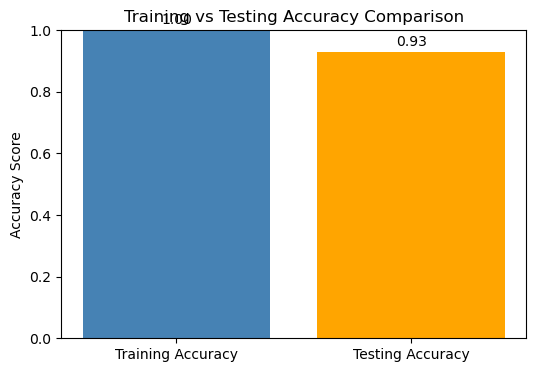

In [33]:
# Predictions
train_pred = rf_model.predict(X_train)
test_pred  = rf_model.predict(X_test)

# Accuracy values
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))

acc_diff = train_acc - test_acc

# Overfitting message
if acc_diff > 0.10:
    print("\nOverfitting Detected: Training accuracy is much higher than testing accuracy.")
else:
    print("\nModel Generalization Looks Good: No major overfitting.")


# PLOT: TRAIN VS TEST ACCURACY


plt.figure(figsize=(6,4))

plt.bar(["Training Accuracy", "Testing Accuracy"], 
        [train_acc, test_acc], 
        color=["steelblue", "orange"])

plt.ylim(0, 1)
plt.ylabel("Accuracy Score")
plt.title("Training vs Testing Accuracy Comparison")

# Add text labels on bars
plt.text(0, train_acc + 0.02, f"{train_acc:.2f}", ha='center')
plt.text(1, test_acc + 0.02, f"{test_acc:.2f}", ha='center')

plt.show()


**STEP 6 — CONFUSION MATRIX**


 Why important in hospitals?

False Negatives = MDR patient missed → very dangerous

False Positives = non-MDR patient wrongly flagged → wastes resources

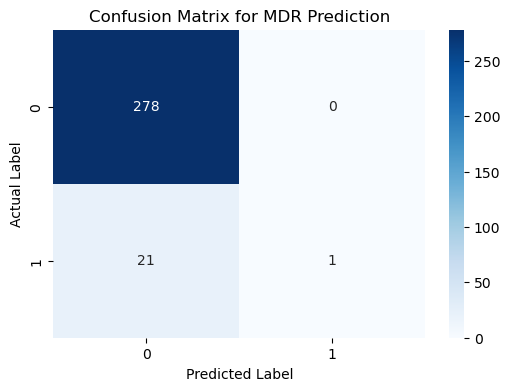

In [34]:
# Generate confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for MDR Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


**STEP 7 — CAT PLOT (Count Plot for MDR vs Non-MDR)**
 Why this step?

Before trusting the model, we must visualize how many MDR and non-MDR records exist.

If dataset is imbalanced → model becomes biased

If one class is too small → accuracy becomes misleading

 What this plot shows

A bar chart with:

Count of 0 (Non-MDR)

Count of 1 (MDR)

This helps confirm if our class distribution is healthy.

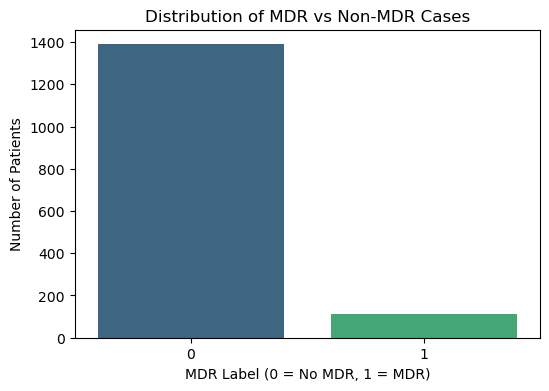

In [35]:
plt.figure(figsize=(6, 4))

# Assign y to a dataframe so seaborn handles it smoothly
sns.countplot(
    data=pd.DataFrame({"MDR_label": y}),
    x="MDR_label",
    hue="MDR_label",
    palette="viridis",
    legend=False
)

plt.title("Distribution of MDR vs Non-MDR Cases")
plt.xlabel("MDR Label (0 = No MDR, 1 = MDR)")
plt.ylabel("Number of Patients")

plt.show()

**STEP 8 — Feature Importance**
- Why this step?

Random Forest tells us which features have the most impact on predicting MDR.

Important in healthcare because:

Doctors want to know why a prediction was made

Research teams can validate which symptoms truly matter

Weak features can be removed to reduce noise

- Special note

Since we used manual encoding earlier (not pipeline-based encoding), we must:

Fit a fresh OneHotEncoder on the categorical columns

Reconstruct the full feature name list

Extract feature importances from the trained model

C:\Users\MONIKHA\AppData\Local\Temp\ipykernel_26184\3619075159.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="Importance", y="Feature", palette="rocket")


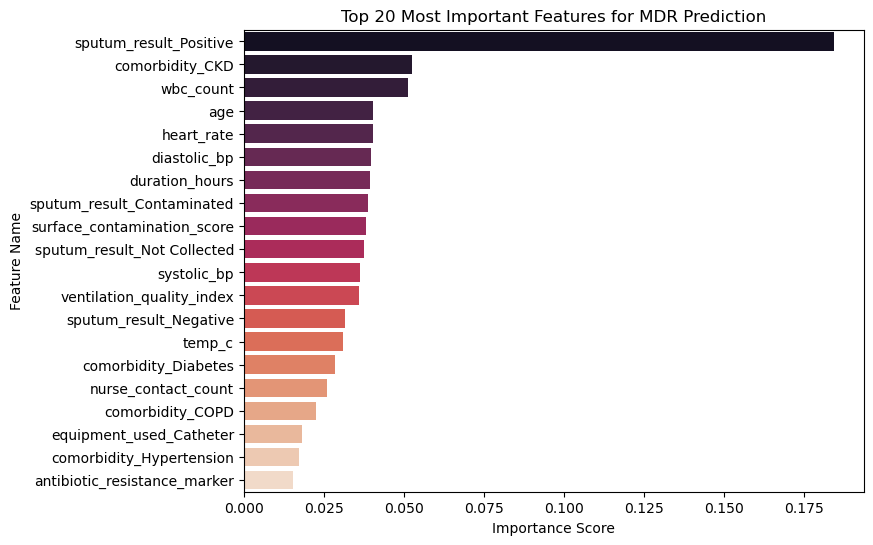

In [36]:
# Fit OneHotEncoder again to categorical data
temp_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
temp_encoder.fit(X_categorical)

# Get encoded column names
encoded_names = temp_encoder.get_feature_names_out(categorical_cols)

# Combine numeric + encoded names
all_feature_names = list(numeric_cols) + list(encoded_names)

# Extract importance values from Random Forest
importance_values = rf_model.feature_importances_

# Create a dataframe
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

# Select top 20
top20 = importance_df.head(20)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=top20, x="Importance", y="Feature", palette="rocket")

plt.title("Top 20 Most Important Features for MDR Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")

plt.show()
